## **Network of thermodynamic neurons**

with the addition of the *signal qubit.* <br>Here we introuce the coupling mechanism. The excitation of the signal qubit indicates that the output for a neuron is $0$ and triggers a switch from $1$ to $0$ for the input of the following neuron. There is a detector which monitors the signal qubit for the duration of thermalisation, if at any point the qubit is excited then the output is switched from the default $1$ to $0$. Once this


Here we also plot the excited population of the signal qubit coupled to the NOT gate.
And see tables for probabilistic behaviour of gate output with signal qubit.

In [ ]:
import numpy as np
from scipy import integrate

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import pyplot
import matplotlib.transforms as transforms

#%pip install qutip
#from google.colab import drive
#drive.mount('/content/drive')

from qutip import *
import pickle

import tqdm
import time
import random
import pandas as pd
import math

These functions are used in eahc gate and do not depend on the number of heat baths/qubits in the neuron.<br>
- **gibbs**  <br>
Input: qubit Hamiltonian $H$, inverse temperature of heat bath $β$ <br>
Output: steady state of qubit - full set of probabilities of grounda and excited state.
- **fermi** <br>
Input: inverse temperature of heat bath $β$, qubit energy gap $ϵ$ <br>
Output: probability qubit is in excited state - Fermi-Dirac distribution.
- **monitor_signal**: <br>
Decides whether the signal qubit is excited based on its excited population at a give time.

In [ ]:
def gibbs(beta, H): # steady state

    matrix = (-beta*H).expm()
    matrix = matrix / matrix.tr()

    return matrix

def fermi(beta, e):

    return 1 / (1+np.exp(beta*e))

def monitor_signal(excited_pop):
    random_number = random.random() # value between 0 and 1
    if random_number<excited_pop:
      return True # qubit in excited state
    else:
      return False # qubit in ground state

*3q in the function name indicates that the function deals with 1 input qubit (NOT), ie: three qubits in the Collector.<br> 4q indicates that there are 2 input qubits (AND, OR).*

- **jump** <br>
Input: ρ (density operator), C (Krause operators ($L_k$) for a particular qubit $k$)<br>
Output: Apply Kraus operators to the density matrix - dissipator for Lindblad master equation $L_kρL_k^†-\frac{1}{2}\{L_k^\dagger L_k,ρ\}$ <br>


In [ ]:
def jump_3q(rho, C):

    if type(C) is list:
        D = Qobj(np.zeros((16, 16)), dims=[[2, 2, 2, 2], [2, 2, 2, 2]]) # 3-qubit + signal qubit Hilbert space
        for item in C:
            D = D + item*rho*item.dag() - 0.5 * commutator(rho, item.dag()*item, 'anti')
    if type(C) is Qobj:
        D = C*rho*C.dag() - 0.5 * commutator(rho, C.dag()*C, 'anti')

    return D

def jump_4q(rho, C):

    if type(C) is list:
        D = Qobj(np.zeros((32, 32)), dims=[[2, 2, 2, 2, 2], [2, 2, 2, 2, 2]]) # 4-qubit + signal qubit Hilbert space
        for item in C:
            D = D + item*rho*item.dag() - 0.5 * commutator(rho, item.dag()*item, 'anti')
    if type(C) is Qobj:
        D = C*rho*C.dag() - 0.5 * commutator(rho, C.dag()*C, 'anti')

    return D

- **get_Kraus_dissipators**<br>
Input: energy gaps of qubits, temperature of baths, other parameters <br>
Output: Kraus operators - $L^{(k)}_{ab}= \sqrt{γ_k}|aXb|_k ⨂ I_{rest} $ for each qubit and $x,y∈\{0,1\}$

In [ ]:
def get_Kraus_dissipators_3q(energies, betas, params):

    e0 = energies['e0']
    e1 = energies['e1']
    eT = energies['eT']
    eS = energies['eS']

    beta0 = betas['beta0']
    beta1 = betas['beta1']
    betaT = betas['betaT']

    gamma0 = params['gamma0']
    gamma1 = params['gamma1']
    gammaT = params['gammaT']
    gammaS = params['gammaS']

    # local Hamiltonians
    m = Qobj(np.array([[0, 0], [0, 1]])) # zero energy in ground state
    h0 = e0 * m
    h1 = e1 * m
    hT = eT * m
    hS = eS * m

    # bath gibbs states (for dissipators) = steady state
    tau0 = gibbs(beta0, h0)
    tau1 = gibbs(beta1, h1)
    tauT = gibbs(betaT, hT)
    tauS = gibbs(betaT, hS)

    # define jump operators (reset model)
    b00 = Qobj([[1,0], [0,0]])
    b01 = Qobj([[0,1], [0,0]])
    b10 = Qobj([[0,0], [1,0]])
    b11 = Qobj([[0,0], [0,1]])

    # jump operators for qubit 0:
    K0_00 = np.sqrt(gamma0 * tau0[0,0]) * tensor(b00, qeye(2), qeye(2), qeye(2))
    K0_01 = np.sqrt(gamma0 * tau0[0,0]) * tensor(b01, qeye(2), qeye(2), qeye(2))
    K0_10 = np.sqrt(gamma0 * tau0[1,1]) * tensor(b10, qeye(2), qeye(2), qeye(2))
    K0_11 = np.sqrt(gamma0 * tau0[1,1]) * tensor(b11, qeye(2), qeye(2), qeye(2))

    # jump operators for qubit 1:
    K1_00 = np.sqrt(gamma1 * tau1[0,0]) * tensor(qeye(2), b00, qeye(2), qeye(2))
    K1_01 = np.sqrt(gamma1 * tau1[0,0]) * tensor(qeye(2), b01, qeye(2), qeye(2))
    K1_10 = np.sqrt(gamma1 * tau1[1,1]) * tensor(qeye(2), b10, qeye(2), qeye(2))
    K1_11 = np.sqrt(gamma1 * tau1[1,1]) * tensor(qeye(2), b11, qeye(2), qeye(2))

    # jump operators for qubit T:
    KT_00 = np.sqrt(gammaT * tauT[0,0]) * tensor(qeye(2), qeye(2), b00, qeye(2))
    KT_01 = np.sqrt(gammaT * tauT[0,0]) * tensor(qeye(2), qeye(2), b01, qeye(2))
    KT_10 = np.sqrt(gammaT * tauT[1,1]) * tensor(qeye(2), qeye(2), b10, qeye(2))
    KT_11 = np.sqrt(gammaT * tauT[1,1]) * tensor(qeye(2), qeye(2), b11, qeye(2))

    # jump operators for qubit T:
    KS_00 = np.sqrt(gammaS * tauS[0,0]) * tensor(qeye(2), qeye(2), qeye(2), b00)
    KS_01 = np.sqrt(gammaS * tauS[0,0]) * tensor(qeye(2), qeye(2), qeye(2), b01)
    KS_10 = np.sqrt(gammaS * tauS[1,1]) * tensor(qeye(2), qeye(2), qeye(2), b10)
    KS_11 = np.sqrt(gammaS * tauS[1,1]) * tensor(qeye(2), qeye(2), qeye(2), b11)

    return {'K0': [K0_00, K0_01, K0_10, K0_11], 'K1': [K1_00, K1_01, K1_10, K1_11],'KT': [KT_00, KT_01, KT_10, KT_11],'KS': [KS_00, KS_01, KS_10, KS_11]}

def get_Kraus_dissipators_4q(energies, betas, params):

    e0 = energies['e0']
    e1 = energies['e1']
    e2 = energies['e2']
    eT = energies['eT']
    eS = energies['eS']

    beta0 = betas['beta0']
    beta1 = betas['beta1']
    beta2 = betas['beta2']
    betaT = betas['betaT']

    gamma0 = params['gamma0']
    gamma1 = params['gamma1']
    gamma2 = params['gamma2']
    gammaT = params['gammaT']
    gammaS = params['gammaS']

    # local Hamiltonians
    m = Qobj(np.array([[0, 0], [0, 1]])) # zero energy in ground state
    h0 = e0 * m
    h1 = e1 * m
    h2 = e2 * m
    hT = eT * m
    hS = eS * m

    # bath gibbs states (for dissipators) = steady state
    tau0 = gibbs(beta0, h0)
    tau1 = gibbs(beta1, h1)
    tau2 = gibbs(beta2, h2)
    tauT = gibbs(betaT, hT)
    tauS = gibbs(betaT, hS)

    # define jump operators (reset model)
    b00 = Qobj([[1,0], [0,0]])
    b01 = Qobj([[0,1], [0,0]])
    b10 = Qobj([[0,0], [1,0]])
    b11 = Qobj([[0,0], [0,1]])

    # jump operators for heat bath 0:
    K0_00 = np.sqrt(gamma0 * tau0[0,0]) * tensor(b00, qeye(2), qeye(2), qeye(2), qeye(2))
    K0_01 = np.sqrt(gamma0 * tau0[0,0]) * tensor(b01, qeye(2), qeye(2), qeye(2), qeye(2))
    K0_10 = np.sqrt(gamma0 * tau0[1,1]) * tensor(b10, qeye(2), qeye(2), qeye(2), qeye(2))
    K0_11 = np.sqrt(gamma0 * tau0[1,1]) * tensor(b11, qeye(2), qeye(2), qeye(2), qeye(2))

    # jump operators for heat bath 1:
    K1_00 = np.sqrt(gamma1 * tau1[0,0]) * tensor(qeye(2), b00, qeye(2), qeye(2), qeye(2))
    K1_01 = np.sqrt(gamma1 * tau1[0,0]) * tensor(qeye(2), b01, qeye(2), qeye(2), qeye(2))
    K1_10 = np.sqrt(gamma1 * tau1[1,1]) * tensor(qeye(2), b10, qeye(2), qeye(2), qeye(2))
    K1_11 = np.sqrt(gamma1 * tau1[1,1]) * tensor(qeye(2), b11, qeye(2), qeye(2), qeye(2))

    # jump operators for heat bath 2:
    K2_00 = np.sqrt(gamma2 * tau2[0,0]) * tensor(qeye(2), qeye(2), b00, qeye(2), qeye(2))
    K2_01 = np.sqrt(gamma2 * tau2[0,0]) * tensor(qeye(2), qeye(2), b01, qeye(2), qeye(2))
    K2_10 = np.sqrt(gamma2 * tau2[1,1]) * tensor(qeye(2), qeye(2), b10, qeye(2), qeye(2))
    K2_11 = np.sqrt(gamma2 * tau2[1,1]) * tensor(qeye(2), qeye(2), b11, qeye(2), qeye(2))

    # jump operators for heat bath T:
    KT_00 = np.sqrt(gammaT * tauT[0,0]) * tensor(qeye(2), qeye(2), qeye(2), b00, qeye(2))
    KT_01 = np.sqrt(gammaT * tauT[0,0]) * tensor(qeye(2), qeye(2), qeye(2), b01, qeye(2))
    KT_10 = np.sqrt(gammaT * tauT[1,1]) * tensor(qeye(2), qeye(2), qeye(2), b10, qeye(2))
    KT_11 = np.sqrt(gammaT * tauT[1,1]) * tensor(qeye(2), qeye(2), qeye(2), b11, qeye(2))

    KS_00 = np.sqrt(gammaS * tauS[0,0]) * tensor(qeye(2), qeye(2), qeye(2), qeye(2), b00)
    KS_01 = np.sqrt(gammaS * tauS[0,0]) * tensor(qeye(2), qeye(2), qeye(2), qeye(2), b01)
    KS_10 = np.sqrt(gammaS * tauS[1,1]) * tensor(qeye(2), qeye(2), qeye(2), qeye(2), b10)
    KS_11 = np.sqrt(gammaS * tauS[1,1]) * tensor(qeye(2), qeye(2), qeye(2), qeye(2), b11)

    return {'K0':[K0_00,K0_01,K0_10,K0_11],'K1':[K1_00,K1_01,K1_10,K1_11],'K2':[K2_00,K2_01,K2_10,K2_11],'KT':[KT_00,KT_01,KT_10,KT_11],'KS': [KS_00,KS_01,KS_10,KS_11]}

- **evolve_to_steady_state** <br>
Input: energies gaps of qubits, temperature of baths, other parameters <br>
Output: steady state solution to Lindblad master equation $\dotρ = -i[H,ρ]+ L[\rho] = 0$, <br>where $H$ is the Hamiltonian of the system and $L$ is the interaction with the baths (dissipators as considered above) <br>
 as well as heat currents for each qubit; $J_k = Tr(HL^{(k)}[\rho])$

In [ ]:
def evolve_to_steady_state_3q(betas, energies, params):
    e0 = energies['e0']
    e1 = energies['e1']
    eT = energies['eT']
    eS = energies['eS']

    beta0 = betas['beta0']
    beta1 = betas['beta1']
    betaT = betas['betaT']

    gamma0 = params['gamma0']
    gamma1 = params['gamma0']
    gammaT = params['gammaT']
    gammaS = params['gammaS']
    g = params['g']

    # local Hamiltonians
    m = Qobj(np.array([[0, 0], [0, 1]]))
    h0 = e0 * m
    h1 = e1 * m
    hT = eT * m
    hS = eS * m

    # interacting Hamiltonian
    m = np.zeros((8,8))
    m[3,4] = g * np.pi/2
    m[4,3] = g * np.pi/2
    Hint = tensor(Qobj(m),qeye(2))

    id2 = qeye(2)
    H0 = tensor(h0, id2, id2, id2)
    H1 = tensor(id2, h1, id2, id2)
    HT = tensor(id2, id2, hT, id2)
    HS = tensor(id2, id2, id2, hS)
    Hint.dims = H0.dims

    Htot =  H0 + H1 + HT + HS + Hint

    # get dissipators
    krauses = get_Kraus_dissipators_3q(energies, betas, params)

    c_ops = []
    for key, item in krauses.items():
        for k in item:
            c_ops.append(k)

    rho_ss = steadystate(Htot, c_ops)

    # heat currents
    J0 = (H0*jump_3q(rho_ss,krauses['K0'])).tr()
    J1 = (H1*jump_3q(rho_ss,krauses['K1'])).tr()
    JT = (HT*jump_3q(rho_ss,krauses['KT'])).tr()
    JS = (HT*jump_3q(rho_ss,krauses['KS'])).tr()

    J = {'J0': J0, 'J1': J1, 'JT': JT, 'JS': JS}

    return rho_ss, J  # returns steady state density matrix and heat currents from qubits to baths

def evolve_to_steady_state_4q(betas, energies, params):
    e0 = energies['e0']
    e1 = energies['e1']
    e2 = energies['e2']
    eT = energies['eT']
    eS = energies['eS']

    beta0 = betas['beta0']
    beta1 = betas['beta1']
    beta2 = betas['beta2']
    betaT = betas['betaT']

    gamma0 = params['gamma0']
    gamma1 = params['gamma1']
    gamma2 = params['gamma2']
    gammaT = params['gammaT']
    gammaS = params['gammaS']
    g = params['g']

    # local Hamiltonians
    m = Qobj(np.array([[0, 0], [0, 1]]))
    h0 = e0 * m
    h1 = e1 * m
    h2 = e2 * m
    hT = eT * m
    hS = eS * m

    # interacting Hamiltonian
    m = np.zeros((16,16))
    m[6,9] = g * np.pi/2
    m[9,6] = g * np.pi/2
    Hint = tensor(Qobj(m),qeye(2))

    id2 = qeye(2)
    H0 = tensor(h0, id2, id2, id2, id2)
    H1 = tensor(id2, h1, id2, id2, id2)
    H2 = tensor(id2, id2, h2, id2, id2)
    HT = tensor(id2, id2, id2, hT, id2)
    HS = tensor(id2, id2, id2, id2, hS)
    Hint.dims = H0.dims

    Htot =  H0 + H1 + H2 + HT + HS + Hint

    # get dissipators
    krauses = get_Kraus_dissipators_4q(energies, betas, params)

    c_ops = []
    for key, item in krauses.items():
        for k in item:
            c_ops.append(k)

    rho_ss = steadystate(Htot, c_ops)

    # heat currents
    J0 = (H0*jump_4q(rho_ss,krauses['K0'])).tr()
    J1 = (H1*jump_4q(rho_ss,krauses['K1'])).tr()
    J2 = (H2*jump_4q(rho_ss,krauses['K2'])).tr()
    JT = (HT*jump_4q(rho_ss,krauses['KT'])).tr()
    JS = (HS*jump_4q(rho_ss,krauses['KS'])).tr()

    J = {'J0': J0, 'J1': J1, 'J2': J2, 'JT': JT, 'JS': JS}

    return rho_ss, J   # returns steady state density matrix and heat currents from qubits to baths

 - **compute_TC_tests**<br>
 Input: temperatures of baths, energy gaps of qubits, other parameters <br>
 Output: determines steady state output temperature, by modelling the thermalisation as a for loop, finding the steady state after each time interval $it$ and updating the currents and temperature of the output bath.

In [ ]:
def compute_TC_tests_3q(betas, energies, params, params_fb):

    betaT_initial = params_fb['betaT_initial']
    Nbath = params_fb['Nbath']
    tint = params_fb['tint']
    C = params_fb['C']
    beta0 = betas['beta0']
    betaR = betas['betaR']
    beta1 = betas['beta1']
    betaT = betaT_initial
    eT = energies['eT']
    gammaR = params['gammaR']

    prob_excited = np.zeros(Nbath)
    beta_time = np.zeros(Nbath)

    # loop over temperatures (dynamics of the output bath)
    for it in range(0,Nbath):
        all_betas = {'beta0': beta0, 'beta1': beta1, 'betaT': betaT, 'betaR': betaR}

        # evolve to steady state
        rho_ss, J = evolve_to_steady_state_3q(all_betas, energies, params)

        rho_signal = rho_ss.ptrace(3)
        excited_pop = np.real(rho_signal[1,1])
        result = monitor_signal(excited_pop)
        prob_excited[it] = excited_pop
        beta_time[it] = betaT
        #if result == True:
         # print("Signal qubit excited at T = ",it)
         # betaT = 0
         # break


        gt = fermi(betaT, eT)
        gr = fermi(betaR, eT)

        # update the output temperature
        J0 = J['J0']
        J1 = J['J1']
        JT = J['JT']
        JR = (gammaR*eT)*(gt-gr)
        JS = J['JS']

        betaT = betaT + (JT+JR+JS)*tint/C

    return betaT, beta_time, prob_excited

def compute_TC_tests_4q(betas, energies, params, params_fb):

    betaT_initial = params_fb['betaT_initial']
    Nbath = params_fb['Nbath']
    tint = params_fb['tint']
    C = params_fb['C']
    beta0 = betas['beta0']
    betaR = betas['betaR']
    beta1 = betas['beta1']
    beta2 = betas['beta2']
    betaT = betaT_initial
    eT = energies['eT']
    gammaR = params['gammaR']

    beta_time = np.zeros(Nbath)
    prob_excited = np.zeros(Nbath)
    # loop over temperatures (dynamics of the output bath)
    for it in range(0, Nbath):
        all_betas = {'beta0': beta0, 'beta1': beta1, 'beta2': beta2, 'betaT': betaT, 'betaR': betaR}

        # evolve to steady state
        rho_ss, J = evolve_to_steady_state_4q(all_betas, energies, params)


        rho_signal = rho_ss.ptrace(4)
        excited_pop = np.real(rho_signal[1,1])
        result = monitor_signal(excited_pop)
        prob_excited[it] = excited_pop
        #if result == True:
          #print("Signal qubit excited at T = ",it)
          #betaT = 0
          #break
        beta_time[it] = betaT

        gt = fermi(betaT, eT)
        gr = fermi(betaR, eT)

        # update the output temperature
        JT = J['JT']
        JR = (gammaR*eT)*(gt-gr)
        JS = J['JS']

        betaT = betaT + (JT+JR+JS)*tint/C
    return betaT,beta_time, prob_excited

**NOT gate** <br>
Input: input inverse temperature<br>
Output: corresponding **NOT** inverse temperature

In [ ]:
def NOT(beta1_input):
    # Parameters
    a = 10
    d = 0.1
    beta0 = 0.5

    # derived params
    e0 = a+d
    e1 = a
    eT = d
    eS = a

    delta = (1 / ((1/2) -  1/(1 + np.exp(d)))) - 1
    betaR = (1 / d) * np.log((1/2) * (1 + np.exp(d)))

    # transient parameters
    betaT_initial = 0.5          # initial temperature of output (T)
    tint = int(1e6)              # parameters for coarse-grained evolution of temperature
    C = 1
    Nbath = int(1.5e2)             # Nin t = cut-off time (# iterations) for the bath dynamics
    gamma0 = 1 # at-bath interactions
    gamma1 = 1
    gammaT = 1e-6
    gammaS = 1e-6
    gammaR = delta*gammaT
    g = 1     # qubit-qubit interactions


    energies = {'e0': e0, 'e1': e1, 'eT': eT, 'eS': eS}
    params = {'gamma0': gamma0, 'gamma1': gamma1, 'gammaT': gammaT,'gammaS':gammaS, 'gammaR': gammaR, 'g': g}
    params_fb = {'betaT_initial': betaT_initial, 'C': C, 'tint': tint, 'Nbath': Nbath}

    beta_min = 0
    beta_max = 1
    betaT = 0.5
    all_betas = {'beta0': beta0, 'beta1': beta1_input, 'betaT': betaT, 'betaR': betaR}
    betas = all_betas

    beta_output, beta_time, prob_excited = compute_TC_tests_3q(betas, energies, params, params_fb)

    print("\nNOT ", beta1_input, " = ", beta_output)
    #if beta_output != 0:
      #beta_output = 1
    return beta_output, beta_time, prob_excited

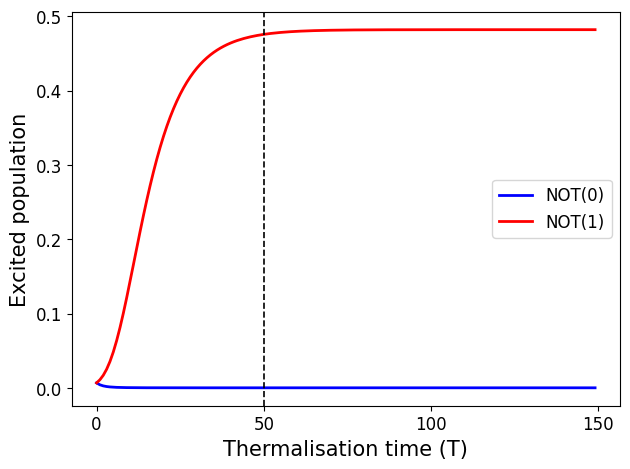

In [ ]:
#output0, beta_time0, prob_excitedNOT0 = NOT(0)
#output1, beta_time1, prob_excitedNOT1 = NOT(1)

# Plot excited populations for each input when we allow full thermalisation even in case of signal qubit excitation
plt.figure()
plt.plot(prob_excitedNOT0, color='blue', label='NOT(0)', linewidth=2)
plt.plot(prob_excitedNOT1, color='red', label='NOT(1)', linewidth=2)

plt.xlabel('Thermalisation time (T)', fontsize = 15)
plt.ylabel('Excited population', fontsize = 15)
plt.xticks([0, 50, 100, 150], fontsize=12)
plt.axvline(x=50, color='black', linestyle='--', linewidth=1.2)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='center right')
plt.tight_layout()
plt.show()

**AND gate** <br>
Input: two input inverse temperature <br>
Output: corresponding **AND** inverse temperature

In [ ]:
def AND(beta1_input, beta2_input):
    # Parameters
    a = 10
    d = 0.1
    beta0 = 1/(d+(4/3))

    # derived params
    e0 = a*abs(d+(4/3))
    e1 = (2/3)*a
    e2 = (2/3)*a
    eT = d
    eS = a

    delta = (1 / ((1/2) -  1/(1 + np.exp(d)))) - 1
    betaR = (1 / d) * np.log((1/2) * (1 + np.exp(d)))

    # transient parameters
    betaT_initial = 0.5          # initial temperature of output (T)
    tint = int(1e6)              # parameters for coarse-grained evolution of temperature
    C = 1
    Nbath = int(1.5e2)             # Nin t = cut-off time (# iterations) for the bath dynamics
    gamma0 = 1 # at-bath interactions
    gamma1 = 1
    gamma2 = 1
    gammaT = 1e-6
    gammaS = 1e-6
    gammaR = delta*gammaT
    g = 1     # qubit-qubit interactions

    energies = {'e0': e0, 'e1': e1, 'e2': e2, 'eT': eT, 'eS': eS}
    params = {'gamma0': gamma0, 'gamma1': gamma1, 'gamma2': gamma2, 'gammaT': gammaT, 'gammaS': gammaS, 'gammaR': gammaR, 'g': g}
    params_fb = {'betaT_initial': betaT_initial, 'C': C, 'tint': tint, 'Nbath': Nbath}

    beta_min = 0
    beta_max = 1
    betaT = 0.5
    all_betas = {'beta0': beta0, 'beta1': beta1_input, 'beta2': beta2_input, 'betaT': betaT, 'betaR': betaR}
    betas = all_betas

    beta_output, beta_time, prob_excited = compute_TC_tests_4q(betas, energies, params, params_fb)

    #if beta_output != 0:
     # beta_output = 1
    print("\n", beta1_input," AND ", beta2_input, " = ", beta_output)

    return beta_output, beta_time, prob_excited

In [ ]:
# Gate Outputs for AND gate for full thermalisation
beta_output1, beta_time1, prob_excitedAND00 = AND(0,0)
beta_output2, beta_time2, prob_excitedAND01 = AND(0,1)
beta_output3, beta_time3, prob_excitedAND10 = AND(1,0)
beta_output4, beta_time4, prob_excitedAND11 = AND(1,1)


 0  AND  0  =  4.920927923996604e-05

 0  AND  1  =  0.03596153436667726

 1  AND  0  =  0.035961537382368486

 1  AND  1  =  0.9457589448765582


**OR gate**<br>
Input: two input inverse temperatures <br>
Output: corresponding **OR** output inverse temperature

In [ ]:
def OR(beta1, beta2):
  # Parameters
  a = 10
  d = 0.1
  beta0 = 1/(d + 4)

  # derived params
  e0 = a*(d+4)
  e1 = 2*a
  e2 = 2*a
  eT = d
  eS = a


  delta = (1 / ((1/2) -  1/(1 + np.exp(d)))) - 1
  betaR = (1 / d) * np.log((1/2) * (1 + np.exp(d)))


  # transient parameters
  betaT_initial = 0.5          # initial temperature of output (T)
  tint = int(1e6)              # parameters for coarse-grained evolution of temperature
  C = 1
  Nbath = int(1.5e2)             # Nin t = cut-off time (# iterations) for the bath dynamics
  gamma0 = 1 # at-bath interactions
  gamma1 = 1
  gamma2 = 1
  gammaT = 1e-6
  gammaS = 1e-6
  gammaR = delta*gammaT
  g = 1     # qubit-qubit interactions


  energies = {'e0': e0, 'e1': e1, 'e2': e2, 'eT': eT, 'eS': eS}
  params = {'gamma0': gamma0, 'gamma1': gamma1, 'gamma2': gamma2, 'gammaT': gammaT,'gammaS':gammaS, 'gammaR': gammaR, 'g': g}
  params_fb = {'betaT_initial': betaT_initial, 'C': C, 'tint': tint, 'Nbath': Nbath}
  beta_min = 0
  beta_max = 1
  betaT = 0.5
  all_betas = {'beta0': beta0, 'beta1': beta1, 'beta2': beta2, 'betaT': betaT, 'betaR': betaR}
  betas = all_betas


  beta_output, beta_time, prob_excited = compute_TC_tests_4q(betas, energies, params, params_fb)

  #if beta_output > 0.0:
   # beta_output = 1
  print(beta1, "OR ", beta2, " = ", beta_output)

  return beta_output, beta_time, prob_excited

In [ ]:
# Gate Outputs for AND gate when thermalisation stop for signal qubit excitation
beta_output1, beta_time1, prob_excitedOR00 = OR(0,0)
beta_output2, beta_time2, prob_excitedOR01 = OR(0,1)
beta_output3, beta_time3, prob_excitedOR10 = OR(1,0)
beta_output4, beta_time4, prob_excitedOR11 = OR(1,1)

0 OR  0  =  4.921359520825771e-05
0 OR  1  =  0.9580114510530257
1 OR  0  =  0.9580114510534333
1 OR  1  =  0.9780827152482084


Below is the code for the network speedup. Instead of computing each gate, all the possible outputs are saved and used to skip the thermalisation step. <br>
- **evaluate_condition_therm** <br>
Input: observation (object being considered), condition (rule from corrent memory distribution <br>
Output: $'1'$ if all features satisfy condition ($1$) and $0$ if any fail ($0$).<br>
- **compute**<br>
Input: feature value, literal value, negated literal value (all $0$s or $1$s)
Output: output value ($0$ or $1$) corresponding to input case. These values have been saved from the full thermalisation network.
- **analyse_performance** <br>
Input: none.
Ouput: results considering all the possible inputs, printed in a table to allow comparison to expected values.

In [ ]:
def evaluate_condition_therm(observation, condition):
    result = 1
    for i in range(len(observation)):
        output = compute(observation[i], condition[0,2*i],condition[0,2*i+1])
        result = AND(result, output)
    final_result = measure_temp(result)
    return final_result

def compute(x,c1,c2):
    start = time.time()
    NOTx = NOT(x)
    NOTc1 = NOT(c1)
    NOTc2 = NOT(c2)

    outputA1 = AND(NOTx, NOTc1)
    outputA2 = AND(x, c1)

    outputB1 = OR(outputA1, outputA2)
    outputB2 = AND(x, NOTc2)

    outputC = OR(outputB1, outputB2)
    end = time.time()
    run_time = round(end-start, 4)
    return outputC, run_time

def analyse_performance():
    t000, time1 = compute(0,0,0)
    t100, time2 = compute(1,0,0)
    t001, time3 = compute(0,0,1)
    t101, time4 = compute(1,0,1)
    t010, time5 = compute(0,1,0)
    t110, time6 = compute(1,1,0)
    avg_run_time = (time1+time2+time3+time4+time5+time6)/6
    #finding = compute(0,0,0)
    alpha = 10
    epsilon_z = 0.1
    print("Avg. run time:", avg_run_time)
    print(fr'\alpha = {alpha}, \epsilon_z = {epsilon_z}')
    print("  x_j  |  c_2j  | c_2j+1 | expect | output  | error ")
    print("  0    |   0    |   0    |   1    |", t000, " |", 1-t000)
    print("  1    |   0    |   0    |   1    |", t100, " |", 1-t100)
    print("  0    |   0    |   1    |   1    |", t001, " |", 1-t001)
    print("  1    |   0    |   1    |   0    |", t101, " |", t101)
    print("  0    |   1    |   0    |   0    |", t010, " |",t010)
    print("  1    |   1    |   0    |   1    |", t110, " |", 1-t110)


In [ ]:
#analyse_performance()

In [ ]:
T = [25, 50, 100, 150] # different thermalisation time (values of Nbath) rows of tables

# conditional probabilities: output given input for different thermalisation times

# NOT: 0|0, 1|0, 0|1, 1|1  (columns)
NOT_probs = np.zeros((4,4))
for i in range(0,4):
  NOT_probs[i][0] = 1 - math.prod([1 - x for x in prob_excitedNOT0[:T[i]]]) # 0|0
  NOT_probs[i][1] = np.prod([1 - x for x in prob_excitedNOT0[:T[i]]]) # 1|0
  NOT_probs[i][2] = 1-np.prod([1 - x for x in prob_excitedNOT1[:T[i]]]) # 0|1
  NOT_probs[i][3] = np.prod([1 - x for x in prob_excitedNOT1[:T[i]]]) # 1|1


# AND/OR: 0|00, 1|00, 0|01, 1|01, 0|10, 1|10, 0|11, 1|11
AND_probs = np.zeros((4,8))
OR_probs = np.zeros((4,8))
def calc_probs(probs, excited_00, excited_01, excited_10, excited_11):
  for i in range(0,4):
    probs[i][0] = 1-np.prod([1-x for x in excited_00[:T[i]]]) # 0|00
    probs[i][1] = np.prod([1-x for x in excited_00[:T[i]]]) # 1|00
    probs[i][2] = 1- np.prod([1-x for x in excited_01[:T[i]]]) # 0|01
    probs[i][3] = np.prod([1-x for x in excited_01[:T[i]]]) # 1|01
    probs[i][4] = 1-np.prod([1-x for x in excited_10[:T[i]]]) #  0|10
    probs[i][5] = np.prod([1-x for x in excited_10[:T[i]]]) # 1|10
    probs[i][6] = 1-np.prod([1-x for x in excited_11[:T[i]]]) # 0|11
    probs[i][7] = np.prod([1-x for x in excited_11[:T[i]]]) # 1|11
  return probs

AND_probs = calc_probs(AND_probs, prob_excitedAND00, prob_excitedAND01, prob_excitedAND10, prob_excitedAND11)
OR_probs = calc_probs(OR_probs, prob_excitedOR00, prob_excitedOR01, prob_excitedOR10, prob_excitedOR11)

# Table of probabilities for False positive/negatives for each gate at T=50
# P(output|expected)
false_output = pd.DataFrame({
    'P(0|1)': [NOT_probs[1][0], AND_probs[1][6], OR_probs[1][2]+OR_probs[1][4]+OR_probs[1][6]],
    'P(1|0)': [NOT_probs[1][3], AND_probs[1][1]+AND_probs[1][3]+AND_probs[1][5], OR_probs[1][1]]
}, index=['NOT', 'AND', 'OR'])

false_output.to_csv('incorrect_output.csv')
false_output_table = false_output.map(lambda x: f"{x:.4g}")
print("Prob(output | expected), T= 50")
print(false_output_table)
print("=========================================================================")
# Table for each gate with probability of correct and incorrect output
NOT_accuracy = pd.DataFrame({'P(True output)': (NOT_probs[:,1]+NOT_probs[:,2])/2,
                            'P(False output)': (NOT_probs[:,0]+NOT_probs[:,3])/2
                            }, index=pd.Index(['25', '50', '100', '150'], name='T'))
NOT_accuracy_table = NOT_accuracy.map(lambda x: f"{x:.4g}")
print('Probability that NOT gate will produce correct or incorrect output for each thermalisation time (T)')
print(NOT_accuracy_table)
print("=========================================================================")
AND_accuracy = pd.DataFrame({'P(True output)': (AND_probs[:,0]+AND_probs[:,2]+AND_probs[:,4]+AND_probs[:,7])/4,
                            'P(False output)':(AND_probs[:,1]+AND_probs[:,3]+AND_probs[:,5]+AND_probs[:,6])/4
                            }, index=pd.Index(['25', '50', '100', '150'], name='T'))
AND_accuracy_table = AND_accuracy.map(lambda x: f"{x:.4g}")
print('Probability that AND gate will produce correct or incorrect output for each thermalisation time (T)')
print(AND_accuracy_table)
print("=========================================================================")
OR_accuracy = pd.DataFrame({'P(True output)': (OR_probs[:,0]+OR_probs[:,3]+OR_probs[:,5]+OR_probs[:,7])/4,
                            'P(False output)':(OR_probs[:,1]+OR_probs[:,2]+OR_probs[:,4]+OR_probs[:,6])/4
                            }, index=pd.Index(['25', '50', '100', '150'], name='T'))
OR_accuracy_table = OR_accuracy.map(lambda x: f"{x:.4g}")
print('Probability that OR gate will produce correct or incorrect output for each thermalisation time (T)')
print(OR_accuracy_table)
print("=========================================================================")
NOT_correct = NOT_accuracy['P(True output)']
AND_correct = AND_accuracy['P(True output)']
OR_correct = OR_accuracy['P(True output)']

# Probability of error free computation for network
network_performance = pd.DataFrame({'P(error free)':((NOT_correct**3)*(AND_correct**3)*(OR_correct**2)),
                                    'P(gate failure)':(1-(NOT_correct**3)*(AND_correct**3)*(OR_correct**2))
                                    }, index=pd.Index(['25', '50', '100', '150'], name='T'))
network_performance_table = network_performance.map(lambda x: f"{x:.4g}")
print('Probability of error free computation for the network')
print(network_performance_table)


Prob(output | expected), T= 50
      P(0|1)     P(1|0)
NOT  0.02237  1.262e-09
AND  0.02569   1.26e-07
OR    0.0729  4.307e-10
Probability that NOT gate will produce correct or incorrect output for each thermalisation time (T)
    P(True output) P(False output)
T                                 
25          0.9875         0.01246
50          0.9888         0.01119
100         0.9876         0.01237
150         0.9864         0.01355
Probability that AND gate will produce correct or incorrect output for each thermalisation time (T)
    P(True output) P(False output)
T                                 
25          0.9881         0.01192
50          0.9936        0.006422
100         0.9926        0.007376
150         0.9917        0.008321
Probability that OR gate will produce correct or incorrect output for each thermalisation time (T)
    P(True output) P(False output)
T                                 
25          0.9824         0.01761
50          0.9818         0.01822
100         0.